In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py

import torch
from torch.utils.data import DataLoader, TensorDataset
import snntorch.functional
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

from SNN_model import CNNBench, EEG2DCNN
from SNN_data import load_data, mat_dataset_load, label_balancing

         Only Prophesee DVS demo will not run properly.
         Please install it from https://github.com/prophesee-ai/prophesee-automotive-dataset-toolbox
      subject  video  channel  label  \
0           1      1        1      1   
1           1      1        2      1   
2           1      1        3      1   
3           1      1        4      1   
4           1      1        5      1   
...       ...    ...      ...    ...   
5791       23     18       10      0   
5792       23     18       11      0   
5793       23     18       12      0   
5794       23     18       13      0   
5795       23     18       14      0   

                                              EEG_clean  
0     [14.19483074338, 25.3864378318111, 18.64942435...  
1     [14.0753200063426, 25.2375213531402, 18.574955...  
2     [10.7344739335759, 19.9674180375432, 14.766619...  
3     [10.4885784173851, 19.600889181045, 14.5989099...  
4     [9.44296317731912, 17.8849312110148, 13.394256...  
...           

In [2]:
# =============================================================================
# Configuration
# =============================================================================

CONFIG = {
    "fs": 128,                # Sampling frequency (Hz)
    "decision_window": 3,     # Window duration (seconds)
    "in_channels": 14,        # The simultan
    "out_channels": 50,       # Number of conv filters / hidden units
    "dropout": 0.25,           # Dropout probability
    "batch_size": 8,          # 1 batch = 1 trial (1 subject vs. 1 video)
    "n_classes": 4,
    "lr":  1e-4,
    "num_epochs": 500,
    "batch": 32,
    "save_dir": "./data/checkpoints",
}

# =============================================================================
# Training & evaluation
# =============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Run one training epoch. Returns total loss."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, labels in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        data = data.unsqueeze(1)
        data = data.permute(0,1,3,2) 

        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
        
    acc = correct / total
    return total_loss/total, acc



@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, labels in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        data = data.unsqueeze(1)
        data = data.permute(0,1,3,2) 

        logits = model(data)
        loss = criterion(logits, labels)

        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

        
    acc = correct / total
    return total_loss/total, acc


def main(train_losses,valid_losses,train_accs,valid_accs):
    # ==================== Training Configuration =========================

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize model
    print("================ Initalizing Model ==========================")
    print(f"Device: {device}")

    model = EEG2DCNN(n_classes=CONFIG["n_classes"], input_time=384, input_channels=CONFIG['in_channels']).to(device)
    print(model)

    # criterion = snntorch.functional.loss.ce_rate_loss()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # Training loop with best-model checkpointing
    save_dir = Path(CONFIG["save_dir"])
    save_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = save_dir / "best_model.pt"

    
    # ==================== Training Execution =========================
    print("================ Training Execution ==========================")
    best_valid_acc = 0.0
    for epoch in range(CONFIG["num_epochs"]):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_train_acc = train_acc
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f}  Acc: {valid_acc:.4f}"
        )

    print(f"\nBest validation accuracy: {best_valid_acc:.4f}")
    print(f"Corresponding train accuracy: {best_train_acc:.4f}")

    # Test with best model
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    _, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test accuracy: {test_acc:.4f}")


if __name__ == "__main__":
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []
     # Load data
    print("================ Loadind data ==========================")
    df = mat_dataset_load()
    df = label_balancing(df)
    train_dataset, valid_dataset, test_dataset = load_data(df)

    # DataLoader
    train_loader = DataLoader(dataset= train_dataset, batch_size=CONFIG['batch'], shuffle=True,drop_last=True)
    test_loader = DataLoader(dataset= test_dataset, batch_size=CONFIG['batch'], shuffle=False,drop_last=False)
    valid_loader = DataLoader(dataset= valid_dataset, batch_size=CONFIG['batch'], shuffle=False,drop_last=False) # can't shuffle or the temporarl dynamic will gone
    main(train_losses,valid_losses,train_accs,valid_accs)

================ Loadind data ==========================
df_trials (trial-level):
   trial_id  subject  video  label
0      1001        1      1      1
1      1002        1      2      0
2      1003        1      3      1
3      1004        1      4      1
4      1005        1      5      1
len(df_trials) = 414
Trial-level counts before balance: [0:223, 1:142, 2:28, 3:21]
Using 21 trials per class (total 84).
keep_idx min/max: 0 372
Trial-level counts after balance:
label
0    21
1    21
2    21
3    21
Name: count, dtype: int64
df_bal (segment/channel-level) shape: (1176, 6)
Channel-level label counts after trial balancing:
label_trial
0    294
1    294
2    294
3    294
Name: count, dtype: int64
=== Group-wise split summary ===
Total segment-samples: 17816
Total trials(groups): 84
Train segments: 11401 | groups: 50
Valid segments: 3013 | groups: 17
Test  segments: 3402 | groups: 17
in_channels: 14
window_size: 128, stride: 128
No trial is split across train/valid/test.
==============

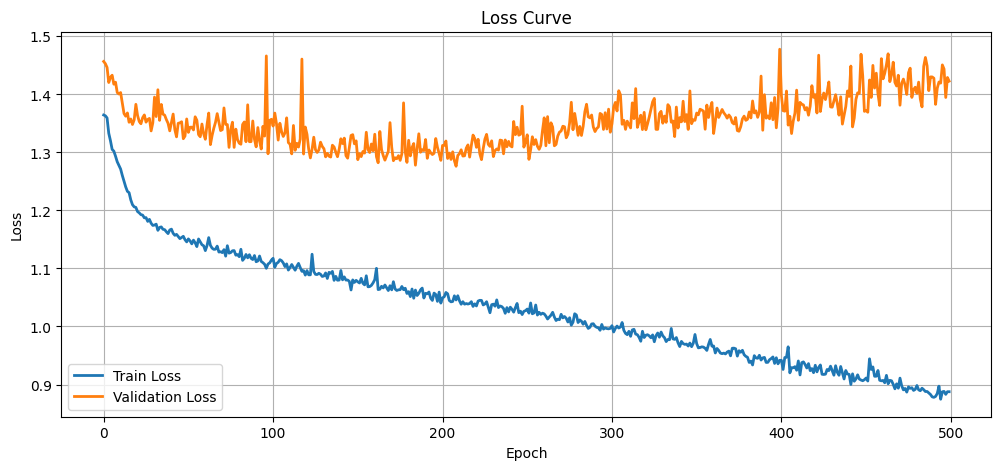

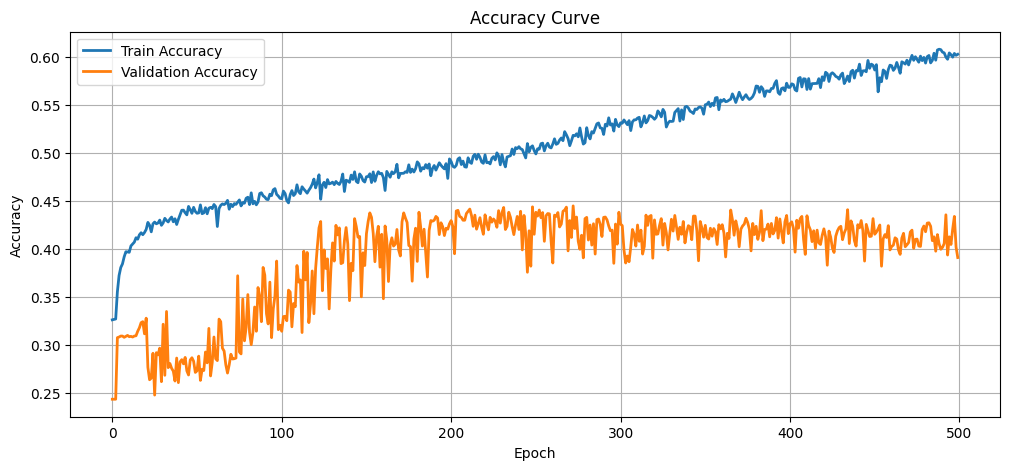

In [4]:
plt.figure(figsize=(12,5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(valid_losses, label='Validation Loss', linewidth=2)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(valid_accs, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()